# PROJECT ML  - Peramalan Inflasi Indonesia (Multivariat)
**Target:** `Inflasi_MoM` | **Model: LSTM, XGBoost, VAR, SVR, CATBOOST | **Split:** 80:20 Temporal

## Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import xgboost as xgb

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, ParameterGrid
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.pipeline import Pipeline

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Alat kerja sudah siap!")

2026-06-12 22:53:59.900087: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781304840.275252      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781304840.373311      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781304841.254760      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781304841.254828      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781304841.254832      16 computation_placer.cc:177] computation placer alr

Alat kerja sudah siap!


## Load & Persiapan Data

In [2]:
# Load dataset
df_raw = pd.read_csv('/kaggle/input/datasets/cahkunondeso/data-ml/clean_inflasi_ts (1).csv')

df_raw['Tanggal'] = pd.to_datetime(df_raw['Tanggal'])
df_raw = df_raw.set_index('Tanggal')
df_raw = df_raw.sort_index()

kolom_hapus = ['Bulan', 'Tahun', 'Inflasi_YoY', 'Inflasi_YtD']
df_raw.drop(columns=kolom_hapus, inplace=True)

print(f"Dimensi data: {df_raw.shape}")
print(f"Rentang waktu: {df_raw.index[0].strftime('%b %Y')} hingga {df_raw.index[-1].strftime('%b %Y')}")
print(f"Total observasi: {len(df_raw)} bulan")
print(f"\nKolom dihapus (leakage / redundan): {kolom_hapus}")
print(f"\nKolom yang tersisa ({len(df_raw.columns)}):")
print(df_raw.columns.tolist())

Dimensi data: (257, 41)
Rentang waktu: Jan 2005 hingga May 2026
Total observasi: 257 bulan

Kolom dihapus (leakage / redundan): ['Bulan', 'Tahun', 'Inflasi_YoY', 'Inflasi_YtD']

Kolom yang tersisa (41):
['Inflasi_MoM', 'IHK', 'BI_Rate', 'Inflasi_Umum_MoM', 'Inflasi_Inti_MoM', 'Inflasi_HargaDiatur_MoM', 'Inflasi_Bergejolak_MoM', 'Harga_Minyak_USD', 'Brent_USD', 'DXY', 'FedRate_Pct', 'Gold_USD', 'CPO_USD', 'GPR_Index', 'FAO_FPI', 'CMO_PalmOil_USD', 'CMO_Coal_AU_USD', 'CMO_Coal_SA_USD', 'CMO_Coffee_Robusta_USD', 'CMO_Coffee_Arabica_USD', 'CMO_Wheat_SRW_USD', 'CMO_Wheat_HRW_USD', 'CMO_Soybeans_USD', 'CMO_SoybeanOil_USD', 'CMO_Sugar_USD', 'CMO_Rubber_TSR20_USD', 'CMO_Rubber_RSS3_USD', 'CMO_Cotton_USD', 'CMO_Rice_Thailand_USD', 'CMO_CoconutOil_USD', 'CMO_Groundnuts_USD', 'CMO_FishMeal_USD', 'CMO_Maize_USD', 'CMO_Tin_USD', 'CMO_Nickel_USD', 'CMO_Copper_USD', 'CMO_Aluminum_USD', 'CMO_IronOre_USD', 'CMO_NatGas_USD', 'CMO_NatGas_EU_USD', 'CMO_LNG_Japan_USD']


In [3]:
# Cek nilai hilang
nan_summary = df_raw.isnull().sum()
nan_cols = nan_summary[nan_summary > 0]
if len(nan_cols) > 0:
    print("Kolom dengan NaN:")
    print(nan_cols)
    # mengisi NaN dengan metode forward fill 
    df_raw = df_raw.ffill()
    print("\nNaN sudah diisi dengan metode forward fill.")
else:
    print("Tidak ada nilai hilang. Data bersih.")

print(f"\n NaN tersisa setelah interpolasi: {df_raw.isnull().sum().sum()}")

Tidak ada nilai hilang. Data bersih.

 NaN tersisa setelah interpolasi: 0


## Eksplorasi Data (EDA)

In [4]:
# Statistik deskriptif target
print("Statistik Deskriptif: Inflasi_MoM")
print(df_raw['Inflasi_MoM'].describe())
print(f"\nNilai Negatif: {(df_raw['Inflasi_MoM'] < 0).sum()} bulan")
print("Log transform TIDAK digunakan karena Inflasi_MoM bisa bernilai negatif.")
print("Normalisasi menggunakan RobustScaler.")

Statistik Deskriptif: Inflasi_MoM
count    257.000000
mean       0.414436
std        0.718040
min       -0.760000
25%        0.080000
50%        0.280000
75%        0.620000
max        8.700000
Name: Inflasi_MoM, dtype: float64

Nilai Negatif: 48 bulan
Log transform TIDAK digunakan karena Inflasi_MoM bisa bernilai negatif.
Normalisasi menggunakan RobustScaler.


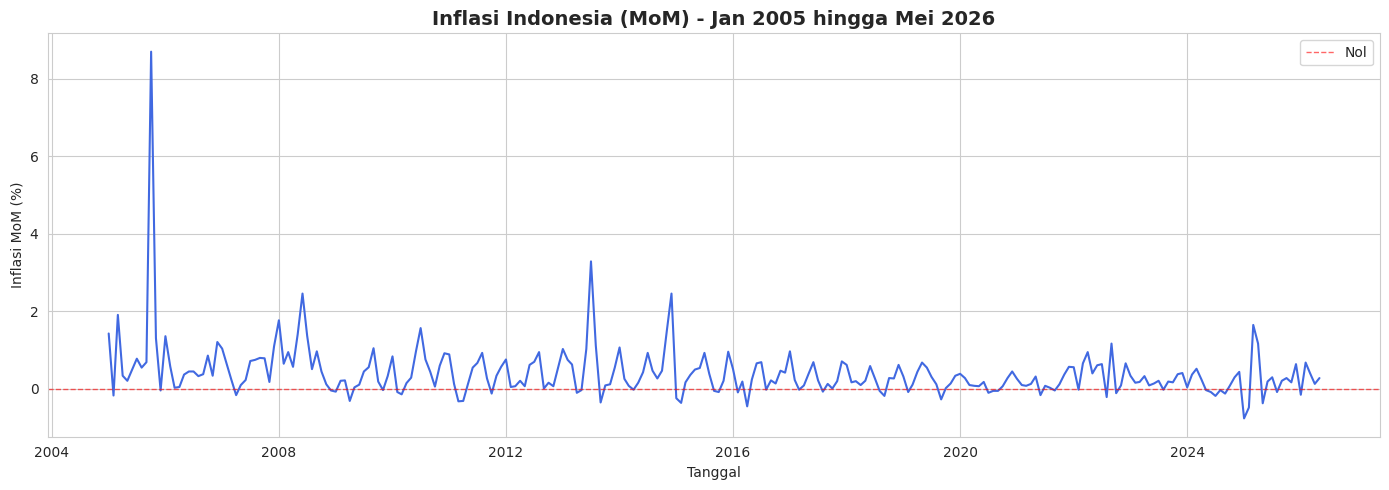

In [5]:
# Plot time series target
plt.figure(figsize=(14, 5))
plt.plot(df_raw.index, df_raw['Inflasi_MoM'], color='royalblue', linewidth=1.5)
plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.6, label='Nol')
plt.title('Inflasi Indonesia (MoM) - Jan 2005 hingga Mei 2026', fontsize=14, fontweight='bold')
plt.xlabel('Tanggal')
plt.ylabel('Inflasi MoM (%)')
plt.legend()
plt.tight_layout()
plt.show()

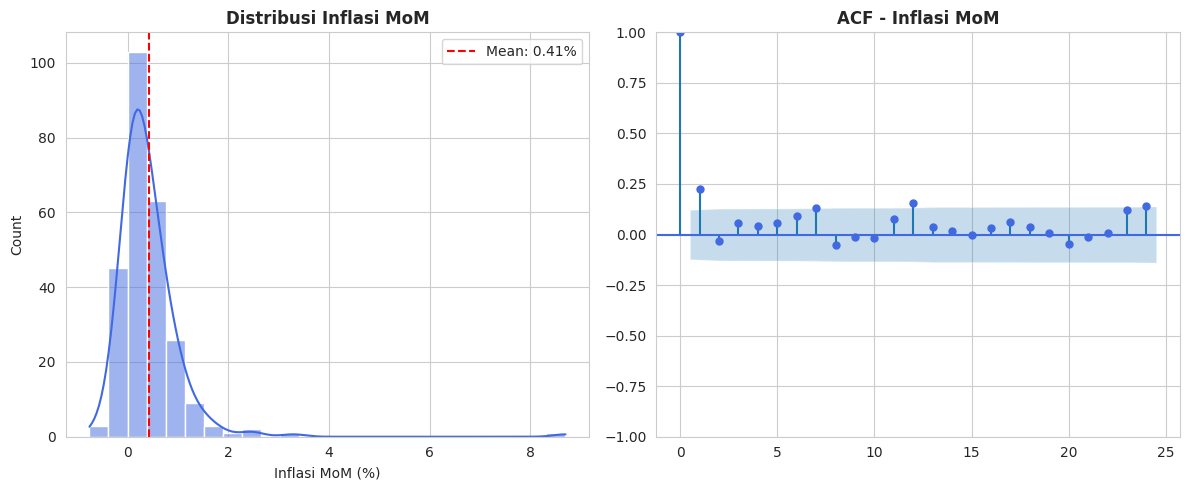

In [6]:
# Distribusi target
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_raw['Inflasi_MoM'], kde=True, color='royalblue', bins=25)
plt.axvline(df_raw['Inflasi_MoM'].mean(), color='red', linestyle='--', label=f"Mean: {df_raw['Inflasi_MoM'].mean():.2f}%")
plt.title('Distribusi Inflasi MoM', fontweight='bold')
plt.xlabel('Inflasi MoM (%)')
plt.legend()

plt.subplot(1, 2, 2)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df_raw['Inflasi_MoM'], lags=24, ax=plt.gca(), color='royalblue')
plt.title('ACF - Inflasi MoM', fontweight='bold')

plt.tight_layout()
plt.show()

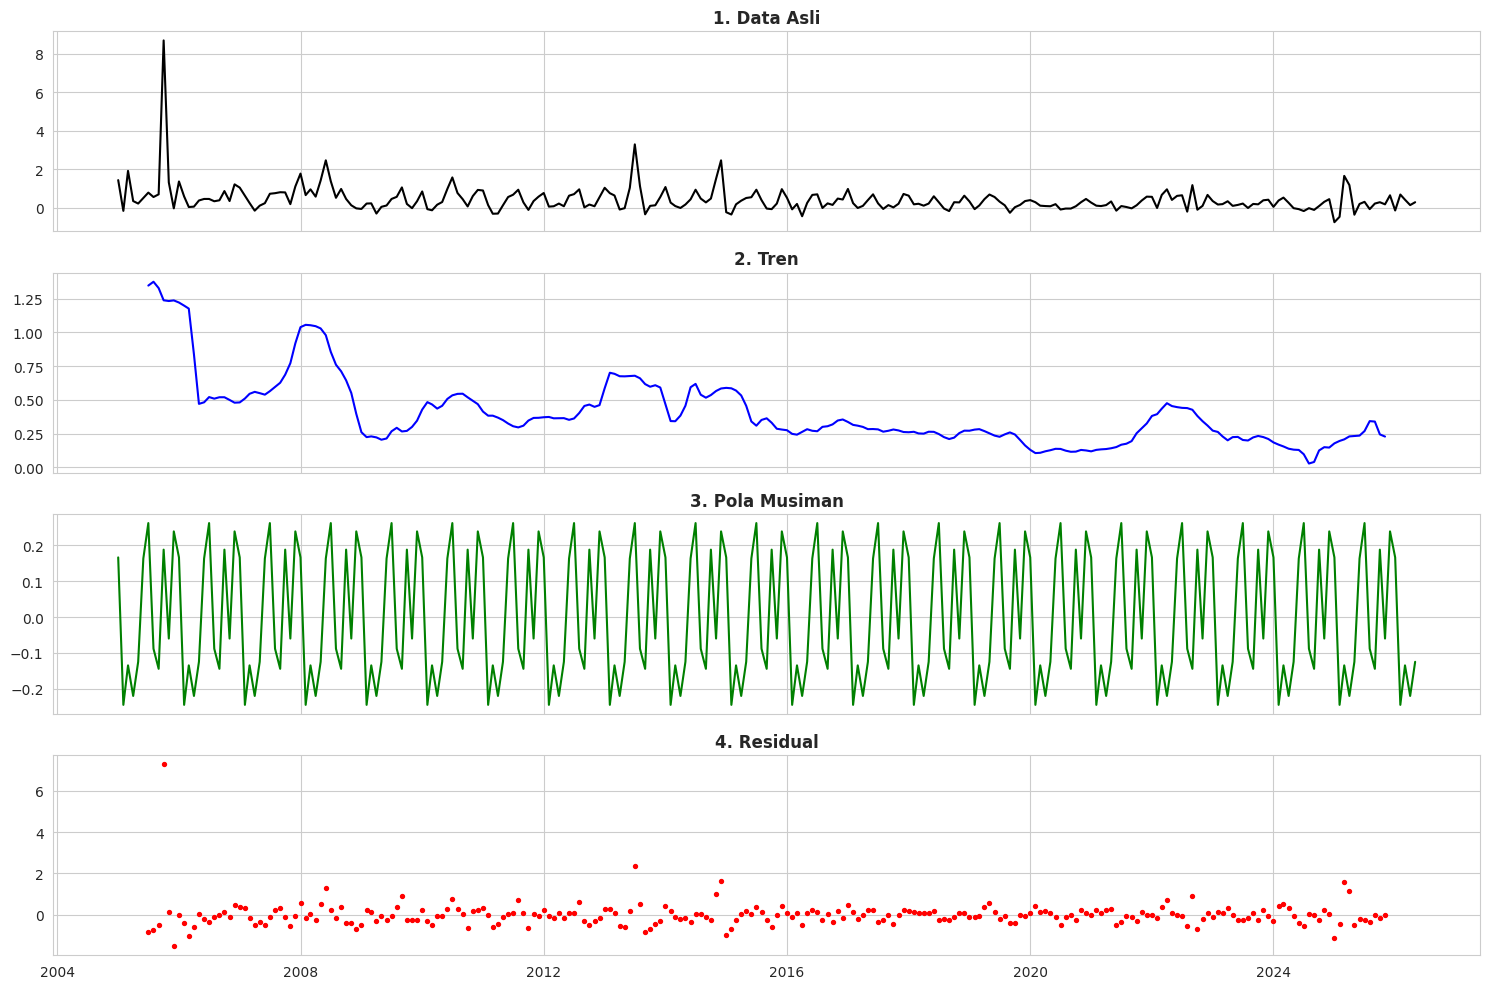

In [7]:
# Dekomposisi musiman
from statsmodels.tsa.seasonal import seasonal_decompose

hasil_bedah = seasonal_decompose(df_raw['Inflasi_MoM'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
axes[0].plot(df_raw['Inflasi_MoM'], color='black'); axes[0].set_title('1. Data Asli', fontweight='bold')
axes[1].plot(hasil_bedah.trend, color='blue'); axes[1].set_title('2. Tren', fontweight='bold')
axes[2].plot(hasil_bedah.seasonal, color='green'); axes[2].set_title('3. Pola Musiman', fontweight='bold')
axes[3].scatter(df_raw.index, hasil_bedah.resid, color='red', s=8); axes[3].set_title('4. Residual', fontweight='bold')
plt.tight_layout()
plt.show()

## Pembagian Data (80:20 Temporal)

In [8]:
# Split 80:20 temporal —
split_idx = int(len(df_raw) * 0.8)
tanggal_pisah = df_raw.index[split_idx]  # Tanggal mulai Test set

print(f"Total data      : {len(df_raw)} bulan")
print(f"Data Latih (80%): {split_idx} bulan  [{df_raw.index[0].strftime('%b %Y')} — {df_raw.index[split_idx-1].strftime('%b %Y')}]")
print(f"Data Uji   (20%): {len(df_raw) - split_idx} bulan  [{df_raw.index[split_idx].strftime('%b %Y')} — {df_raw.index[-1].strftime('%b %Y')}]")
print(f"\nTanggal pisah   : {tanggal_pisah.strftime('%B %Y')}")

Total data      : 257 bulan
Data Latih (80%): 205 bulan  [Jan 2005 — Jan 2022]
Data Uji   (20%): 52 bulan  [Feb 2022 — May 2026]

Tanggal pisah   : February 2022


## Fungsi (Metrik & Visualisasi)

In [9]:
# Fungsi Visualisasi Evaluasi (Sudah disesuaikan untuk Inflasi & WAPE)
def plot_analisis_temporal_inflasi(tanggal, aktual, prediksi, nama_model, warna_prediksi):
    metrik = hitung_metrik_lengkap(aktual, prediksi)
    residual = aktual - prediksi
    
    # Membuat kanvas besar dengan GridSpec
    fig = plt.figure(figsize=(18, 10))
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

    # Plot Aktual vs Prediksi (Garis Waktu)
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(tanggal, aktual, color='black', label='Data Aktual (Test Set)', linewidth=2)
    ax1.plot(tanggal, prediksi, color=warna_prediksi, linestyle='--', 
             label=f'Prediksi {nama_model}', linewidth=2, marker='s')
    ax1.fill_between(tanggal, aktual, prediksi, color=warna_prediksi, alpha=0.1, label='Area Selisih (Error)')
    ax1.set_title(f'Prediksi vs Aktual Inflasi MoM ({nama_model})', fontsize=15, fontweight='bold')
    ax1.set_ylabel('Inflasi MoM (%)')
    ax1.legend(loc='upper left', fontsize=11)
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Scatter Plot (Penyebaran Tebakan)
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.scatter(aktual, prediksi, color=warna_prediksi, alpha=0.7, edgecolor='white', s=60)
    lo, hi = min(aktual), max(aktual)
    ax2.plot([lo, hi], [lo, hi], 'k--', label='Garis Ideal')
    
    # Menempelkan Teks Metrik di dalam box 
    teks_metrik = f"MAE: {metrik['MAE']:,.4f}\nRMSE: {metrik['RMSE']:,.4f}\nWAPE: {metrik['WAPE%']:.2f}%"
    
    ax2.text(0.05, 0.95, teks_metrik, transform=ax2.transAxes, va='top', 
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'), fontsize=12)
    ax2.set_title(f'Scatter Plot Keselarasan ({nama_model})', fontweight='bold')
    ax2.set_xlabel('Nilai Aktual Asli')
    ax2.set_ylabel('Nilai Hasil Prediksi')
    ax2.legend(loc='lower right')

    # Distribusi Residual (Histogram Error)
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.hist(residual, bins=15, color='orange', alpha=0.7, edgecolor='white')
    ax3.axvline(0, color='black', linestyle='--', linewidth=2, label='Error Nol (Sempurna)')
    ax3.axvline(np.mean(residual), color='red', linestyle=':', linewidth=2, label=f'Rata-rata Error: {np.mean(residual):.4f}')
    ax3.set_title(f'Distribusi Kesalahan / Residual ({nama_model})', fontweight='bold')
    ax3.set_xlabel('Nilai Residual (Aktual - Prediksi)')
    ax3.set_ylabel('Frekuensi')
    ax3.legend()
    
    plt.tight_layout()
    plt.show()

## Model LSTM (Multivariat)


### Persiapan Data LSTM

In [10]:
# Semua kolom dipakai, target di posisi pertama untuk kemudahan inverse transform
kolom_fitur_lstm = ['Inflasi_MoM'] + [c for c in df_raw.columns if c != 'Inflasi_MoM']

data_lstm = df_raw[kolom_fitur_lstm].copy()

# Fitur kalender (siklus bulanan)
data_lstm['bulan_sin'] = np.sin(2 * np.pi * data_lstm.index.month / 12.0)
data_lstm['bulan_cos'] = np.cos(2 * np.pi * data_lstm.index.month / 12.0)

n_fitur_lstm = data_lstm.shape[1]
print(f"Jumlah fitur input LSTM: {n_fitur_lstm}")
print(f"Kolom: {data_lstm.columns.tolist()}")

Jumlah fitur input LSTM: 43
Kolom: ['Inflasi_MoM', 'IHK', 'BI_Rate', 'Inflasi_Umum_MoM', 'Inflasi_Inti_MoM', 'Inflasi_HargaDiatur_MoM', 'Inflasi_Bergejolak_MoM', 'Harga_Minyak_USD', 'Brent_USD', 'DXY', 'FedRate_Pct', 'Gold_USD', 'CPO_USD', 'GPR_Index', 'FAO_FPI', 'CMO_PalmOil_USD', 'CMO_Coal_AU_USD', 'CMO_Coal_SA_USD', 'CMO_Coffee_Robusta_USD', 'CMO_Coffee_Arabica_USD', 'CMO_Wheat_SRW_USD', 'CMO_Wheat_HRW_USD', 'CMO_Soybeans_USD', 'CMO_SoybeanOil_USD', 'CMO_Sugar_USD', 'CMO_Rubber_TSR20_USD', 'CMO_Rubber_RSS3_USD', 'CMO_Cotton_USD', 'CMO_Rice_Thailand_USD', 'CMO_CoconutOil_USD', 'CMO_Groundnuts_USD', 'CMO_FishMeal_USD', 'CMO_Maize_USD', 'CMO_Tin_USD', 'CMO_Nickel_USD', 'CMO_Copper_USD', 'CMO_Aluminum_USD', 'CMO_IronOre_USD', 'CMO_NatGas_USD', 'CMO_NatGas_EU_USD', 'CMO_LNG_Japan_USD', 'bulan_sin', 'bulan_cos']


### Split Data LSTM

In [11]:
jumlah_bulan_kebelakang = 12  # lookback window

# Tarik mundur batas awal data uji sebesar lookback agar sekuens pertama test
# tepat meramal bulan pertama test set (tanggal_pisah)
tanggal_awal_uji_lstm = tanggal_pisah - pd.DateOffset(months=jumlah_bulan_kebelakang)

data_latih_lstm = data_lstm[data_lstm.index < tanggal_pisah].copy()
data_uji_lstm   = data_lstm[data_lstm.index >= tanggal_awal_uji_lstm].copy()

print(f"Data latih LSTM : {len(data_latih_lstm)} bulan  [{data_latih_lstm.index[0].strftime('%b %Y')} — {data_latih_lstm.index[-1].strftime('%b %Y')}]")
print(f"Data uji LSTM   : {len(data_uji_lstm)} bulan   [{data_uji_lstm.index[0].strftime('%b %Y')} — {data_uji_lstm.index[-1].strftime('%b %Y')}]")
print(f"Lookback window : {jumlah_bulan_kebelakang} bulan")
print(f"Prediksi uji pertama jatuh di: {tanggal_pisah.strftime('%B %Y')} ")

Data latih LSTM : 205 bulan  [Jan 2005 — Jan 2022]
Data uji LSTM   : 64 bulan   [Feb 2021 — May 2026]
Lookback window : 12 bulan
Prediksi uji pertama jatuh di: February 2022 


### Fungsi Pembuatan Sekuens

In [12]:
def buat_urutan_data(data_input, lookback=12):
    """
    Membuat pasangan (X, y) dari data time series multivariat.
    X: window lookback dari semua fitur
    y: nilai target (kolom 0 = Inflasi_MoM) pada timestep berikutnya
    """
    X, y = [], []
    for i in range(len(data_input) - lookback):
        X.append(data_input[i : i + lookback])
        y.append(data_input[i + lookback, 0])  # kolom 0 = Inflasi_MoM
    return np.array(X), np.array(y)

### Grid Search LSTM

In [13]:
from sklearn.model_selection import ParameterSampler
from tensorflow.keras.layers import BatchNormalization

# Parameter yang lebih realistis untuk time series finansial
pilihan_pengaturan_lstm_luas = {
    'units_layer_1' : [64, 128, 256],      # tingkatkan kapasitas
    'units_layer_2' : [32, 64, 128],
    'dropout'       : [0.1, 0.2, 0.3],     # lebih rendah
    'l2_reg'        : [1e-5, 1e-4, 1e-3], # kurangi regulasi
    'learning_rate' : [0.0001, 0.0005, 0.001],
    'batch_size'    : [16, 32, 64]         # stabilkan gradien
}

# Gunakan 3 fold agar setiap fold cukup panjang (time series)
pembagi_waktu_cv = TimeSeriesSplit(n_splits=3)
kombinasi_acak = ParameterSampler(pilihan_pengaturan_lstm_luas, n_iter=40, random_state=42)

skor_error_terendah = float('inf')
pengaturan_terbaik_lstm = None

print("Proses Random Search LSTM ...")

for pengaturan in kombinasi_acak:
    print(f"Mencoba: {pengaturan}")
    kumpulan_skor = []

    for idx_latih, idx_val in pembagi_waktu_cv.split(data_latih_lstm):
        potongan_latih = data_latih_lstm.values[idx_latih]
        potongan_val   = data_latih_lstm.values[idx_val]

        scaler_sementara = RobustScaler()
        latih_skala = scaler_sementara.fit_transform(potongan_latih)
        val_skala   = scaler_sementara.transform(potongan_val)

        X_latih_cv, y_latih_cv = buat_urutan_data(latih_skala, jumlah_bulan_kebelakang)
        X_val_cv, y_val_cv = buat_urutan_data(val_skala, jumlah_bulan_kebelakang)

        if len(X_latih_cv) == 0 or len(X_val_cv) == 0:
            continue

        model_cv = Sequential([
            Input(shape=(jumlah_bulan_kebelakang, n_fitur_lstm)),
            LSTM(pengaturan['units_layer_1'], activation='tanh', return_sequences=True,
                 kernel_regularizer=l2(pengaturan['l2_reg'])),
            BatchNormalization(),
            Dropout(pengaturan['dropout']),
            LSTM(pengaturan['units_layer_2'], activation='tanh',
                 kernel_regularizer=l2(pengaturan['l2_reg'])),
            BatchNormalization(),
            Dropout(pengaturan['dropout']),
            Dense(32, activation='relu'),
            Dense(1)
        ])
        model_cv.compile(optimizer=Adam(learning_rate=pengaturan['learning_rate']), loss='mse')

        rem = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
        lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=0)

        model_cv.fit(X_latih_cv, y_latih_cv,
                     validation_data=(X_val_cv, y_val_cv),
                     epochs=300, batch_size=pengaturan['batch_size'],
                     callbacks=[rem, lr_reducer], verbose=0)

        pred_cv = model_cv.predict(X_val_cv, verbose=0)
        kumpulan_skor.append(mean_squared_error(y_val_cv, pred_cv))

    if len(kumpulan_skor) == 0:
        continue
    rata_rata_error = np.mean(kumpulan_skor)
    print(f" Rata-rata MSE Validasi: {rata_rata_error:.6f}")

    if rata_rata_error < skor_error_terendah:
        skor_error_terendah = rata_rata_error
        pengaturan_terbaik_lstm = pengaturan

print("\n Parameter Terbaik LSTM:", pengaturan_terbaik_lstm)

Proses Random Search LSTM ...
Mencoba: {'units_layer_2': 32, 'units_layer_1': 64, 'learning_rate': 0.0005, 'l2_reg': 0.001, 'dropout': 0.3, 'batch_size': 32}


2026-06-12 22:54:22.126451: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


 Rata-rata MSE Validasi: 0.481689
Mencoba: {'units_layer_2': 64, 'units_layer_1': 128, 'learning_rate': 0.0005, 'l2_reg': 0.001, 'dropout': 0.2, 'batch_size': 16}
 Rata-rata MSE Validasi: 0.508571
Mencoba: {'units_layer_2': 128, 'units_layer_1': 128, 'learning_rate': 0.0001, 'l2_reg': 0.001, 'dropout': 0.1, 'batch_size': 32}
 Rata-rata MSE Validasi: 0.467639
Mencoba: {'units_layer_2': 64, 'units_layer_1': 128, 'learning_rate': 0.0001, 'l2_reg': 0.0001, 'dropout': 0.2, 'batch_size': 32}
 Rata-rata MSE Validasi: 0.520495
Mencoba: {'units_layer_2': 128, 'units_layer_1': 64, 'learning_rate': 0.0001, 'l2_reg': 0.0001, 'dropout': 0.1, 'batch_size': 64}
 Rata-rata MSE Validasi: 0.517484
Mencoba: {'units_layer_2': 128, 'units_layer_1': 128, 'learning_rate': 0.001, 'l2_reg': 1e-05, 'dropout': 0.1, 'batch_size': 32}
 Rata-rata MSE Validasi: 0.490349
Mencoba: {'units_layer_2': 32, 'units_layer_1': 64, 'learning_rate': 0.001, 'l2_reg': 0.001, 'dropout': 0.1, 'batch_size': 16}
 Rata-rata MSE Valida

### Training Final LSTM

In [14]:
# Scaling final — fit hanya pada data latih
alat_skala_final_lstm = RobustScaler()
latih_full_skala = alat_skala_final_lstm.fit_transform(data_latih_lstm.values)
uji_skala        = alat_skala_final_lstm.transform(data_uji_lstm.values)

X_latih_full, y_latih_full = buat_urutan_data(latih_full_skala, jumlah_bulan_kebelakang)
X_uji_lstm,   y_uji_lstm   = buat_urutan_data(uji_skala,        jumlah_bulan_kebelakang)

# memisahkan 15% akhir data latih sebagai validation set Early Stopping
n_pengawas   = int(len(X_latih_full) * 0.15)
X_latih_final = X_latih_full[:-n_pengawas]
y_latih_final = y_latih_full[:-n_pengawas]
X_pengawas    = X_latih_full[-n_pengawas:]
y_pengawas    = y_latih_full[-n_pengawas:]

# Arsitektur final dengan BatchNormalization 
model_terbaik_lstm = Sequential([
    Input(shape=(jumlah_bulan_kebelakang, n_fitur_lstm)),
    LSTM(pengaturan_terbaik_lstm['units_layer_1'], 
         activation='tanh', 
         return_sequences=True,
         kernel_regularizer=l2(pengaturan_terbaik_lstm['l2_reg'])),
    BatchNormalization(),  
    Dropout(pengaturan_terbaik_lstm['dropout']),
    
    LSTM(pengaturan_terbaik_lstm['units_layer_2'], 
         activation='tanh',
         kernel_regularizer=l2(pengaturan_terbaik_lstm['l2_reg'])),
    BatchNormalization(),
    Dropout(pengaturan_terbaik_lstm['dropout']),
    
    Dense(32, activation='relu'),  
    Dense(1)
])

lr = pengaturan_terbaik_lstm['learning_rate']
if lr < 0.0005:
    lr = 0.001
    print(f"Learning rate dinaikkan dari {pengaturan_terbaik_lstm['learning_rate']} menjadi {lr}")

model_terbaik_lstm.compile(
    optimizer=Adam(learning_rate=lr),
    loss='mse'
)

# Callback dengan patience lebih panjang
pengawas_berhenti = EarlyStopping(monitor='val_loss', 
                                  patience=40,           
                                  restore_best_weights=True,
                                  verbose=1)
turunkan_kecepatan = ReduceLROnPlateau(monitor='val_loss', 
                                       factor=0.5, 
                                       patience=15,       
                                       min_lr=1e-6,      
                                       verbose=1)

print("\n Proses Training Final LSTM (Arsitektur diperkuat)...")
riwayat_pelatihan = model_terbaik_lstm.fit(
    X_latih_final, y_latih_final,
    validation_data=(X_pengawas, y_pengawas),
    epochs=300,                     
    batch_size=pengaturan_terbaik_lstm['batch_size'],
    callbacks=[pengawas_berhenti, turunkan_kecepatan],
    verbose=1
)
print("Training Final LSTM SELESAI!")


 Proses Training Final LSTM (Arsitektur diperkuat)...
Epoch 1/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 154ms/step - loss: 2.4207 - val_loss: 0.4295 - learning_rate: 0.0010
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 1.6949 - val_loss: 0.3967 - learning_rate: 0.0010
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 1.5903 - val_loss: 0.3898 - learning_rate: 0.0010
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 1.3992 - val_loss: 0.3831 - learning_rate: 0.0010
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 1.1691 - val_loss: 0.3759 - learning_rate: 0.0010
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 1.1966 - val_loss: 0.3722 - learning_rate: 0.0010
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 1.1760 - val_loss: 0.3737 - learning_rate: 0.0010
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 1.3193 - val_loss: 0.3697 - learning_rate: 0.0010
Epoch 9/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 1.1302 - val_loss: 0.3

In [15]:
# Fungsi inverse transform
def kembalikan_ke_asli_inflasi(data_tebakan_skala, alat_skala_obj):
    n_fitur = alat_skala_obj.n_features_in_
    tabel_bantuan = np.zeros((len(data_tebakan_skala), n_fitur))
    tabel_bantuan[:, 0] = data_tebakan_skala.ravel()
    return alat_skala_obj.inverse_transform(tabel_bantuan)[:, 0]

# Prediksi test set
tebakan_lstm_skala  = model_terbaik_lstm.predict(X_uji_lstm, verbose=0)
tebakan_lstm_asli   = kembalikan_ke_asli_inflasi(tebakan_lstm_skala, alat_skala_final_lstm)
jawaban_benar_lstm  = kembalikan_ke_asli_inflasi(y_uji_lstm.reshape(-1, 1), alat_skala_final_lstm)

# Simpan ke DataFrame dengan index tanggal yang benar
indeks_uji_lstm = data_uji_lstm.index[jumlah_bulan_kebelakang:]
tabel_hasil_lstm = pd.DataFrame({
    'Data Aktual'       : jawaban_benar_lstm,
    'Prediksi Model LSTM': tebakan_lstm_asli
}, index=indeks_uji_lstm)

print(tabel_hasil_lstm)

            Data Aktual  Prediksi Model LSTM
Tanggal                                     
2022-02-01        -0.02             0.243961
2022-03-01         0.66             0.226578
2022-04-01         0.95             0.223436
2022-05-01         0.40             0.247437
2022-06-01         0.61             0.260092
2022-07-01         0.64             0.306168
2022-08-01        -0.21             0.355885
2022-09-01         1.17             0.398794
2022-10-01        -0.11             0.423308
2022-11-01         0.09             0.427258
2022-12-01         0.66             0.418080
2023-01-01         0.34             0.397642
2023-02-01         0.16             0.377241
2023-03-01         0.18             0.354762
2023-04-01         0.33             0.337763
2023-05-01         0.09             0.342948
2023-06-01         0.14             0.356432
2023-07-01         0.21             0.361118
2023-08-01        -0.02             0.379759
2023-09-01         0.19             0.423670
2023-10-01

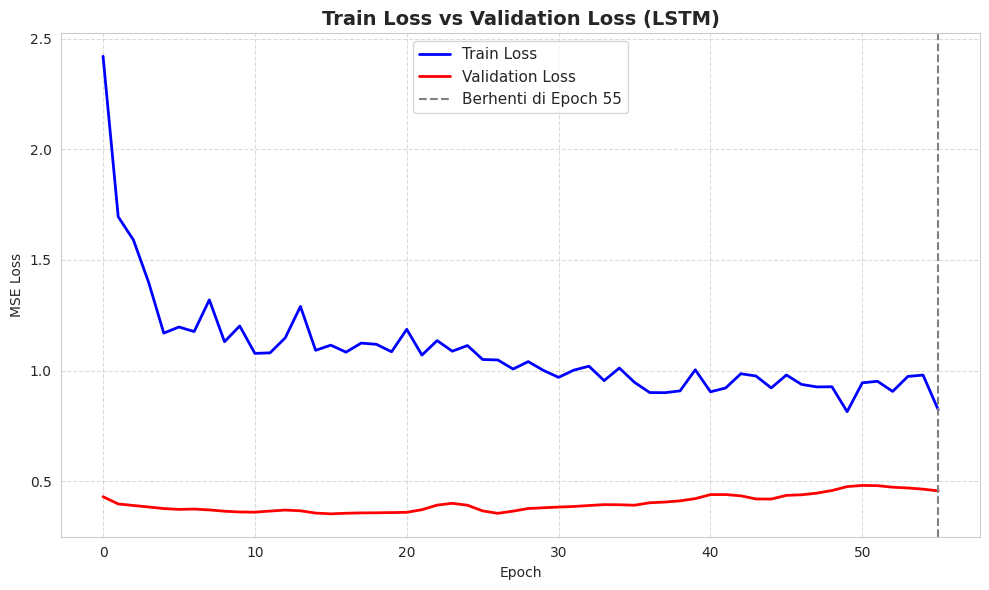

In [16]:
# Plot Train vs Validation Loss
plt.figure(figsize=(10, 6))
plt.plot(riwayat_pelatihan.history['loss'],     label='Train Loss',      color='blue',  linewidth=2)
plt.plot(riwayat_pelatihan.history['val_loss'], label='Validation Loss', color='red',   linewidth=2)
titik_berhenti = len(riwayat_pelatihan.history['loss']) - 1
plt.axvline(x=titik_berhenti, color='gray', linestyle='dashed',
            label=f'Berhenti di Epoch {titik_berhenti}')
plt.title('Train Loss vs Validation Loss (LSTM)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Model XGBoost (Multivariat)
> Fitur multivariat langsung dipakai bersama lag, rolling, dan fitur kalender.

### Feature Engineering XGBoost

In [17]:
# Mulai dari semua kolom kecuali kolom yang sudah dihapus
data_xgb = df_raw.copy()

# Fitur kalender
data_xgb['kuartal']   = data_xgb.index.quarter
data_xgb['bulan_sin'] = np.sin(2 * np.pi * data_xgb.index.month / 12.0)
data_xgb['bulan_cos'] = np.cos(2 * np.pi * data_xgb.index.month / 12.0)

# Lag fitur target (mencegah look-ahead)
for i in [1, 2, 3, 6, 12]:
    data_xgb[f'inflasi_lag_{i}'] = data_xgb['Inflasi_MoM'].shift(i)

# Rolling statistics target (shift(1) mencegah mengintip masa depan)
data_xgb['inflasi_rolling_mean_3']  = data_xgb['Inflasi_MoM'].shift(1).rolling(3).mean()
data_xgb['inflasi_rolling_std_3']   = data_xgb['Inflasi_MoM'].shift(1).rolling(3).std()
data_xgb['inflasi_rolling_mean_6']  = data_xgb['Inflasi_MoM'].shift(1).rolling(6).mean()
data_xgb['inflasi_rolling_std_6']   = data_xgb['Inflasi_MoM'].shift(1).rolling(6).std()
data_xgb['inflasi_rolling_mean_12'] = data_xgb['Inflasi_MoM'].shift(1).rolling(12).mean()

# Hapus baris NaN akibat lag & rolling
data_xgb.dropna(inplace=True)

y_target_xgb = data_xgb['Inflasi_MoM']
X_fitur_xgb  = data_xgb.drop('Inflasi_MoM', axis=1)

print(f"Fitur XGBoost  : {X_fitur_xgb.shape[1]} kolom")
print(f"Observasi valid: {len(X_fitur_xgb)} (setelah dropna)")
print(f"\nDaftar fitur:")
print(X_fitur_xgb.columns.tolist())

Fitur XGBoost  : 53 kolom
Observasi valid: 245 (setelah dropna)

Daftar fitur:
['IHK', 'BI_Rate', 'Inflasi_Umum_MoM', 'Inflasi_Inti_MoM', 'Inflasi_HargaDiatur_MoM', 'Inflasi_Bergejolak_MoM', 'Harga_Minyak_USD', 'Brent_USD', 'DXY', 'FedRate_Pct', 'Gold_USD', 'CPO_USD', 'GPR_Index', 'FAO_FPI', 'CMO_PalmOil_USD', 'CMO_Coal_AU_USD', 'CMO_Coal_SA_USD', 'CMO_Coffee_Robusta_USD', 'CMO_Coffee_Arabica_USD', 'CMO_Wheat_SRW_USD', 'CMO_Wheat_HRW_USD', 'CMO_Soybeans_USD', 'CMO_SoybeanOil_USD', 'CMO_Sugar_USD', 'CMO_Rubber_TSR20_USD', 'CMO_Rubber_RSS3_USD', 'CMO_Cotton_USD', 'CMO_Rice_Thailand_USD', 'CMO_CoconutOil_USD', 'CMO_Groundnuts_USD', 'CMO_FishMeal_USD', 'CMO_Maize_USD', 'CMO_Tin_USD', 'CMO_Nickel_USD', 'CMO_Copper_USD', 'CMO_Aluminum_USD', 'CMO_IronOre_USD', 'CMO_NatGas_USD', 'CMO_NatGas_EU_USD', 'CMO_LNG_Japan_USD', 'kuartal', 'bulan_sin', 'bulan_cos', 'inflasi_lag_1', 'inflasi_lag_2', 'inflasi_lag_3', 'inflasi_lag_6', 'inflasi_lag_12', 'inflasi_rolling_mean_3', 'inflasi_rolling_std_3', 'i

### Split Data XGBoost

In [18]:
X_latih_xgb = X_fitur_xgb[X_fitur_xgb.index < tanggal_pisah]
X_uji_xgb   = X_fitur_xgb[X_fitur_xgb.index >= tanggal_pisah]

y_latih_xgb = y_target_xgb[y_target_xgb.index < tanggal_pisah]
y_uji_xgb   = y_target_xgb[y_target_xgb.index >= tanggal_pisah]

print(f"Data latih XGBoost: {len(X_latih_xgb)} bulan  [{X_latih_xgb.index[0].strftime('%b %Y')} — {X_latih_xgb.index[-1].strftime('%b %Y')}]")
print(f"Data uji   XGBoost: {len(X_uji_xgb)} bulan   [{X_uji_xgb.index[0].strftime('%b %Y')} — {X_uji_xgb.index[-1].strftime('%b %Y')}]")

Data latih XGBoost: 193 bulan  [Jan 2006 — Jan 2022]
Data uji   XGBoost: 52 bulan   [Feb 2022 — May 2026]


### Grid Search XGBoost

In [19]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

jalur_pipa_xgb = Pipeline([
    ('perata_skala', RobustScaler()),
    ('mesin_xgb', xgb.XGBRegressor(objective='reg:squarederror', random_state=42))
])

pilihan_pengaturan_xgb_luas = {
    'mesin_xgb__n_estimators': [1000, 2000, 3000], 
    'mesin_xgb__learning_rate': [0.005, 0.01, 0.05],
    'mesin_xgb__max_depth': [3, 4, 5, 6],
    'mesin_xgb__min_child_weight': [1, 3, 5, 7],
    'mesin_xgb__reg_alpha': [0.1, 1, 5, 10], 
    'mesin_xgb__reg_lambda': [1, 5, 10, 50],
    'mesin_xgb__subsample': [0.6, 0.7, 0.8, 0.9],
    'mesin_xgb__colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'mesin_xgb__gamma': [0.1, 0.3, 0.5, 1.0]
}

pembagi_waktu_xgb = TimeSeriesSplit(n_splits=3)

pencari_acak_xgb = RandomizedSearchCV(
    estimator  = jalur_pipa_xgb,
    param_distributions = pilihan_pengaturan_xgb_luas,
    n_iter     = 300,  # Akan mengambil 300 kombinasi secara acak
    scoring    = 'neg_mean_squared_error',
    n_jobs     = -1,
    random_state = 42, 
    verbose    = 1
)

print("\n Proses Random Search XGBoost ...")
pencari_acak_xgb.fit(X_latih_xgb, y_latih_xgb)

print("\n Parameter terbaik XGBoost dari Random Search:")
print(pencari_acak_xgb.best_params_)

model_terbaik_xgb = pencari_acak_xgb.best_estimator_

# Prediksi test set
tebakan_xgb_asli      = model_terbaik_xgb.predict(X_uji_xgb)
jawaban_benar_xgb     = y_uji_xgb.values

tabel_hasil_xgb = pd.DataFrame({
    'Data Aktual'         : jawaban_benar_xgb,
    'Prediksi Model XGBoost': tebakan_xgb_asli
}, index=y_uji_xgb.index)



 Proses Random Search XGBoost ...
Fitting 5 folds for each of 300 candidates, totalling 1500 fits

 Parameter terbaik XGBoost dari Random Search:
{'mesin_xgb__subsample': 0.7, 'mesin_xgb__reg_lambda': 1, 'mesin_xgb__reg_alpha': 0.1, 'mesin_xgb__n_estimators': 1000, 'mesin_xgb__min_child_weight': 1, 'mesin_xgb__max_depth': 4, 'mesin_xgb__learning_rate': 0.005, 'mesin_xgb__gamma': 0.1, 'mesin_xgb__colsample_bytree': 0.6}


## Fitur Terbaik

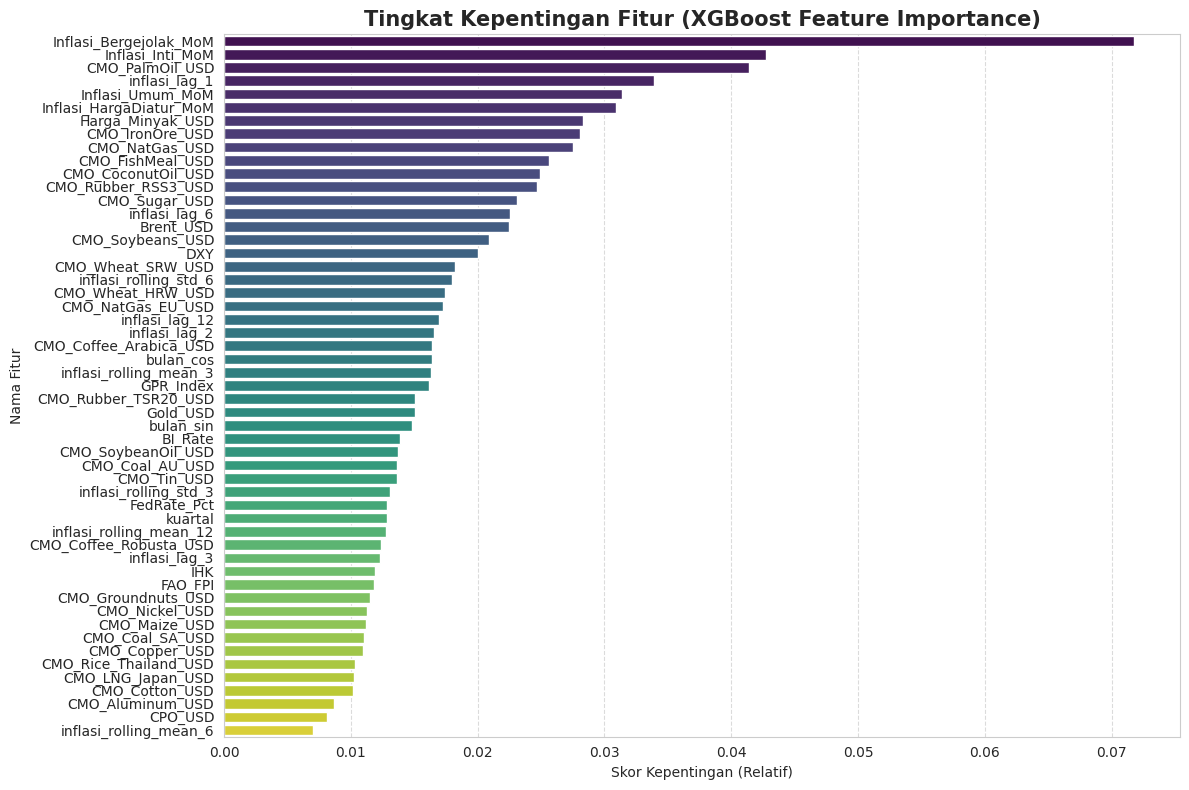


Detail Skor Kepentingan Fitur:


,Fitur,Skor_Kepentingan
5,Inflasi_Bergejolak_MoM,0.071808
3,Inflasi_Inti_MoM,0.042721
14,CMO_PalmOil_USD,0.041421
43,inflasi_lag_1,0.033936
2,Inflasi_Umum_MoM,0.031418
4,Inflasi_HargaDiatur_MoM,0.030871
6,Harga_Minyak_USD,0.028311
36,CMO_IronOre_USD,0.028096
37,CMO_NatGas_USD,0.027489
30,CMO_FishMeal_USD,0.025631


In [20]:
# Ekstrak model XGBoost dari dalam Pipeline
model_xgb_inti = model_terbaik_xgb.named_steps['mesin_xgb']

#nilai bobot kepentingan fitur
bobot_fitur = model_xgb_inti.feature_importances_

#DataFrame agar rapi dan urutkan dari yang paling penting
tabel_penting = pd.DataFrame({
    'Fitur': X_fitur_xgb.columns,
    'Skor_Kepentingan': bobot_fitur
}).sort_values(by='Skor_Kepentingan', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Skor_Kepentingan', y='Fitur', data=tabel_penting, palette='viridis')
plt.title('Tingkat Kepentingan Fitur (XGBoost Feature Importance)', fontsize=15, fontweight='bold')
plt.xlabel('Skor Kepentingan (Relatif)')
plt.ylabel('Nama Fitur')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nDetail Skor Kepentingan Fitur:")
display(tabel_penting)

## Model VAR

In [21]:
from statsmodels.tsa.api import VAR
import warnings
warnings.filterwarnings('ignore')

print("PROSES OPTIMASI VAR (VECTOR AUTOREGRESSION)..")

# Gunakan nama variabel yang benar
fitur_var_terpilih = [
    'Inflasi_MoM', 
    'Inflasi_Bergejolak_MoM', 
    'Inflasi_Inti_MoM', 
    'CMO_PalmOil_USD', 
    'Harga_Minyak_USD'
]

df_fitur_var = df_raw[fitur_var_terpilih] 

# Potong dataset
data_latih_var_kecil = df_fitur_var[df_fitur_var.index < tanggal_pisah].copy()
data_uji_var_kecil   = df_fitur_var[df_fitur_var.index >= tanggal_pisah].copy()

# Model VAR
model_var = VAR(data_latih_var_kecil)
hasil_seleksi_lag = model_var.select_order(maxlags=6)
lag_optimal_var = hasil_seleksi_lag.aic
print(f"Lag optimal (AIC): {lag_optimal_var}")

# Training final
model_terbaik_var = model_var.fit(lag_optimal_var)

# Prediksi multi-step
input_awal_var = data_latih_var_kecil.values[-lag_optimal_var:]
prediksi_var_list = []
input_sekarang = input_awal_var.copy()

for i in range(len(data_uji_var_kecil)):
    tebakan_1_langkah = model_terbaik_var.forecast(y=input_sekarang, steps=1)
    indeks_inflasi = fitur_var_terpilih.index('Inflasi_MoM')
    prediksi_var_list.append(tebakan_1_langkah[0][indeks_inflasi])
    baris_aktual_baru = data_uji_var_kecil.values[i].reshape(1, -1)
    input_sekarang = np.vstack([input_sekarang[1:], baris_aktual_baru])

tebakan_var_asli = np.array(prediksi_var_list)
print("Prediksi VAR Selesai!")

PROSES OPTIMASI VAR (VECTOR AUTOREGRESSION)..
Lag optimal (AIC): 2
Prediksi VAR Selesai!


In [22]:
# Melatih model secara final dengan lag optimal yang didapat
model_terbaik_var = model_var.fit(lag_optimal_var)

# Siapkan input awal dari data latih yang sudah DIPERKECIL dimensinya
input_awal_var = data_latih_var_kecil.values[-lag_optimal_var:]

prediksi_var_list = []
input_sekarang = input_awal_var.copy()

# Looping prediksi langkah demi langkah menggunakan data uji yang sudah diperkecil
for i in range(len(data_uji_var_kecil)):
    # Tebak 1 langkah (bulan) ke depan
    tebakan_1_langkah = model_terbaik_var.forecast(y=input_sekarang, steps=1)
    
    # Ambil nilai prediksi hanya untuk target (Inflasi_MoM)
    indeks_inflasi = fitur_var_terpilih.index('Inflasi_MoM')
    prediksi_var_list.append(tebakan_1_langkah[0][indeks_inflasi])
    
    # Update input dengan data aktual terbaru untuk tebakan bulan berikutnya
    baris_aktual_baru = data_uji_var_kecil.values[i].reshape(1, -1)
    input_sekarang = np.vstack([input_sekarang[1:], baris_aktual_baru])

tebakan_var_asli = np.array(prediksi_var_list)

print(" Prediksi VAR Selesai!")

 Prediksi VAR Selesai!


## Model SVR

In [23]:
from sklearn.svm import SVR

print(" PROSES RANDOM SEARCH SVR..")

jalur_pipa_svr = Pipeline([
    ('perata_skala', RobustScaler()),
    ('mesin_svr', SVR(kernel='rbf')) # RBF cocok untuk pola non-linear inflasi
])

# Ruang parameter SVr
pilihan_pengaturan_svr = {
    'mesin_svr__C': [0.1, 1, 10, 50, 100], # Penalti terhadap error
    'mesin_svr__gamma': ['scale', 'auto', 0.001, 0.01, 0.1], # Jangkauan pengaruh sampel
    'mesin_svr__epsilon': [0.01, 0.05, 0.1, 0.2] # Zona toleransi noise
}

pencari_acak_svr = RandomizedSearchCV(
    estimator  = jalur_pipa_svr,
    param_distributions = pilihan_pengaturan_svr,
    n_iter     = 50, 
    cv         = pembagi_waktu_xgb,
    scoring    = 'neg_mean_squared_error',
    n_jobs     = -1,
    random_state = 42,
    verbose    = 1
)

pencari_acak_svr.fit(X_latih_xgb, y_latih_xgb)

print("\n Parameter terbaik SVR:")
print(pencari_acak_svr.best_params_)

model_terbaik_svr = pencari_acak_svr.best_estimator_

# Prediksi SVR
tebakan_svr_asli = model_terbaik_svr.predict(X_uji_xgb)

 PROSES RANDOM SEARCH SVR..
Fitting 3 folds for each of 50 candidates, totalling 150 fits

 Parameter terbaik SVR:
{'mesin_svr__gamma': 0.001, 'mesin_svr__epsilon': 0.01, 'mesin_svr__C': 50}


## Model CatBoost

In [24]:
!pip install catboost statsmodels

In [25]:
from catboost import CatBoostRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler


print(" PROSES RANDOM SEARCH CATBOOST..")


jalur_pipa_cat = Pipeline([
    ('perata_skala', RobustScaler()),
    ('mesin_cat', CatBoostRegressor(loss_function='RMSE', verbose=False, random_seed=42))
])

# Ruang parameter 
pilihan_pengaturan_cat = {
    'mesin_cat__iterations': [500, 1000, 1500],
    'mesin_cat__learning_rate': [0.01, 0.03, 0.05],
    'mesin_cat__depth': [3, 4, 5, 6], 
    'mesin_cat__l2_leaf_reg': [1, 3, 5, 7, 9], # Regularisasi yang kuat
    'mesin_cat__subsample': [0.7, 0.8, 1.0]
}

pembagi_waktu = TimeSeriesSplit(n_splits=3)

pencari_acak_cat = RandomizedSearchCV(
    estimator  = jalur_pipa_cat,
    param_distributions = pilihan_pengaturan_cat,
    n_iter     = 50,  
    cv         = pembagi_waktu,
    scoring    = 'neg_mean_squared_error',
    n_jobs     = -1,
    random_state = 42,
    verbose    = 1
)

pencari_acak_cat.fit(X_latih_xgb, y_latih_xgb)

print("\n Parameter terbaik CatBoost:")
print(pencari_acak_cat.best_params_)

model_terbaik_cat = pencari_acak_cat.best_estimator_

# Prediksi CatBoost
tebakan_cat_asli = model_terbaik_cat.predict(X_uji_xgb)

 PROSES RANDOM SEARCH CATBOOST..
Fitting 3 folds for each of 50 candidates, totalling 150 fits

 Parameter terbaik CatBoost:
{'mesin_cat__subsample': 0.8, 'mesin_cat__learning_rate': 0.03, 'mesin_cat__l2_leaf_reg': 7, 'mesin_cat__iterations': 1500, 'mesin_cat__depth': 6}


## Mennyimpanan Model untuk Deployment

In [26]:
model_terbaik_lstm.save('model_lstm_inflasi.h5')
print("Model LSTM tersimpan sebagai 'model_lstm_inflasi.h5'")

Model LSTM tersimpan sebagai 'model_lstm_inflasi.h5'


In [27]:
import joblib
joblib.dump(model_terbaik_xgb, 'model_terbaik_xgb.pkl')
joblib.dump(model_terbaik_cat, 'model_terbaik_cat.pkl')
joblib.dump(model_terbaik_svr, 'model_terbaik_svr.pkl')
print("Model XGBoost, CatBoost, dan SVR Pipelines berhasil disimpan.")

Model XGBoost, CatBoost, dan SVR Pipelines berhasil disimpan.


In [28]:
joblib.dump(model_terbaik_var, 'model_terbaik_var.pkl')
print("Model VAR berhasil disimpan.")

Model VAR berhasil disimpan.


## Evaluasi Metrik (Train vs Test)

In [29]:
def hitung_metrik_lengkap(y_asli, y_prediksi):
    y_asli     = np.array(y_asli).flatten()
    y_prediksi = np.array(y_prediksi).flatten()

    rmse = np.sqrt(mean_squared_error(y_asli, y_prediksi))
    mae  = mean_absolute_error(y_asli, y_prediksi)
    
    # Menghitung WAPE (Weighted Absolute Percentage Error)
    total_error_absolut = np.sum(np.abs(y_asli - y_prediksi))
    total_aktual_absolut = np.sum(np.abs(y_asli))
    
    # Mencegah division by zero jika total aktual kebetulan persis 0
    if total_aktual_absolut == 0:
        wape = 0.0 
    else:
        wape = (total_error_absolut / total_aktual_absolut) * 100 

    return {
        'RMSE'  : rmse,
        'MAE'   : mae,
        'WAPE%': wape  
    }

In [30]:

# VALUASI LATIH (TRAIN METRICS)
# LSTM Train
tebakan_latih_lstm_skala = model_terbaik_lstm.predict(X_latih_full, verbose=0)
tebakan_latih_lstm_asli  = kembalikan_ke_asli_inflasi(tebakan_latih_lstm_skala, alat_skala_final_lstm)
jawaban_latih_lstm_asli  = kembalikan_ke_asli_inflasi(y_latih_full.reshape(-1, 1), alat_skala_final_lstm)
metrik_train_lstm = hitung_metrik_lengkap(jawaban_latih_lstm_asli, tebakan_latih_lstm_asli)

# XGBoost, CatBoost, SVR Train
metrik_train_xgb = hitung_metrik_lengkap(y_latih_xgb.values, model_terbaik_xgb.predict(X_latih_xgb))
metrik_train_cat = hitung_metrik_lengkap(y_latih_xgb.values, model_terbaik_cat.predict(X_latih_xgb))
metrik_train_svr = hitung_metrik_lengkap(y_latih_xgb.values, model_terbaik_svr.predict(X_latih_xgb))

# VAR Train 
aktual_train_var = data_latih_var_kecil['Inflasi_MoM'].iloc[lag_optimal_var:].values
prediksi_train_var = model_terbaik_var.fittedvalues['Inflasi_MoM'].values
metrik_train_var = hitung_metrik_lengkap(aktual_train_var, prediksi_train_var)

# EVALUASI UJI (TEST METRICS)
metrik_test_lstm = hitung_metrik_lengkap(jawaban_benar_lstm, tebakan_lstm_asli)
metrik_test_xgb  = hitung_metrik_lengkap(jawaban_benar_xgb,  tebakan_xgb_asli)
metrik_test_cat  = hitung_metrik_lengkap(jawaban_benar_xgb,  tebakan_cat_asli)
metrik_test_svr  = hitung_metrik_lengkap(jawaban_benar_xgb,  tebakan_svr_asli)
metrik_test_var  = hitung_metrik_lengkap(data_uji_var_kecil['Inflasi_MoM'].values, tebakan_var_asli)

# TABEL PERBANDINGAN 
tabel_metrik_final = pd.DataFrame({
    'Model': ['LSTM', 'LSTM', 'XGBoost', 'XGBoost', 'CatBoost', 'CatBoost', 'SVR', 'SVR', 'VAR', 'VAR'],
    'Fase' : ['Train', 'Test', 'Train', 'Test', 'Train', 'Test', 'Train', 'Test', 'Train', 'Test'],
    'RMSE' : [metrik_train_lstm['RMSE'],  metrik_test_lstm['RMSE'],  metrik_train_xgb['RMSE'],  metrik_test_xgb['RMSE'],
              metrik_train_cat['RMSE'],  metrik_test_cat['RMSE'],  metrik_train_svr['RMSE'],  metrik_test_svr['RMSE'],
              metrik_train_var['RMSE'],  metrik_test_var['RMSE']],
    'MAE'  : [metrik_train_lstm['MAE'],   metrik_test_lstm['MAE'],   metrik_train_xgb['MAE'],   metrik_test_xgb['MAE'],
              metrik_train_cat['MAE'],   metrik_test_cat['MAE'],   metrik_train_svr['MAE'],   metrik_test_svr['MAE'],
              metrik_train_var['MAE'],   metrik_test_var['MAE']],
    'WAPE (%)': [metrik_train_lstm['WAPE%'], metrik_test_lstm['WAPE%'], metrik_train_xgb['WAPE%'], metrik_test_xgb['WAPE%'],
                 metrik_train_cat['WAPE%'], metrik_test_cat['WAPE%'], metrik_train_svr['WAPE%'], metrik_test_svr['WAPE%'],
                 metrik_train_var['WAPE%'], metrik_test_var['WAPE%']]
})

display(tabel_metrik_final.style.format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'WAPE (%)': '{:.2f}%'}))

,Model,Fase,RMSE,MAE,WAPE (%)
0,LSTM,Train,0.4762,0.3292,73.93%
1,LSTM,Test,0.4437,0.3502,98.27%
2,XGBoost,Train,0.1105,0.0668,15.01%
3,XGBoost,Test,0.1874,0.1068,29.97%
4,CatBoost,Train,0.0099,0.0078,1.75%
5,CatBoost,Test,0.2101,0.1328,37.27%
6,SVR,Train,0.1435,0.0445,9.98%
7,SVR,Test,0.2266,0.1863,52.28%
8,VAR,Train,0.7157,0.3510,70.59%
9,VAR,Test,0.5339,0.3975,111.55%


## Visualisasi

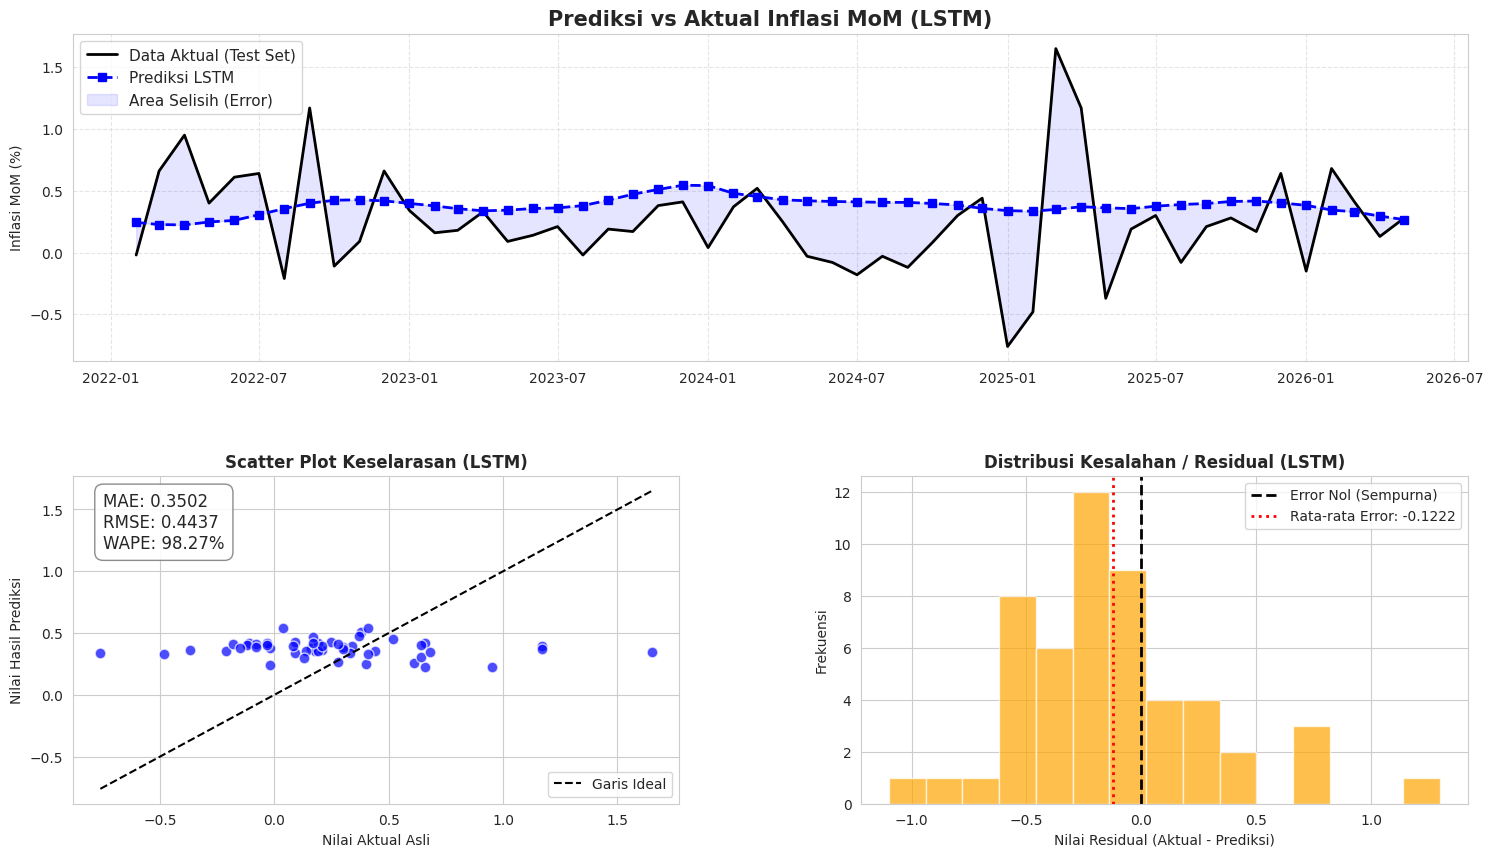

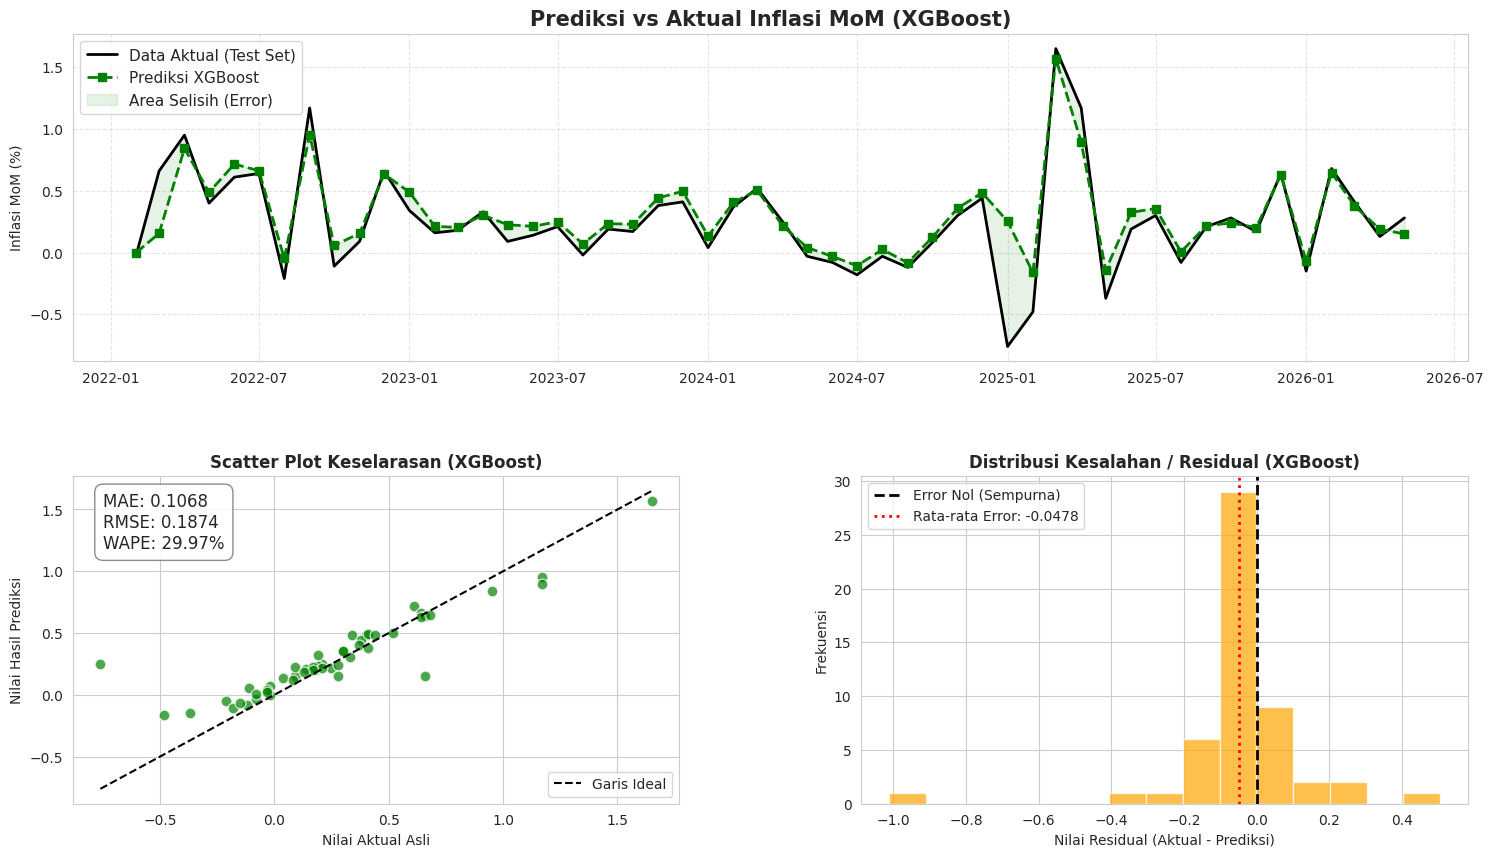

In [31]:
plot_analisis_temporal_inflasi(indeks_uji_lstm, jawaban_benar_lstm, tebakan_lstm_asli, "LSTM", "blue")
plot_analisis_temporal_inflasi(y_uji_xgb.index, jawaban_benar_xgb, tebakan_xgb_asli, "XGBoost", "green")

In [32]:
# Membuat kalender 12 bulan ke depan dari tanggal terakhir data
tanggal_terakhir = df_raw.index[-1]
kalender_masa_depan = pd.date_range(start=tanggal_terakhir + pd.DateOffset(months=1), periods=12, freq='MS')

# FORECAST DENGAN LSTM (12 BULAN MULTIVARIAT)
urutan_terakhir_lstm = uji_skala[-jumlah_bulan_kebelakang:].copy()
hasil_ramalan_lstm_skala = []

for tanggal in kalender_masa_depan:
    # Tebak bulan depan
    input_ramalan = urutan_terakhir_lstm.reshape(1, jumlah_bulan_kebelakang, n_fitur_lstm)
    tebakan = model_terbaik_lstm.predict(input_ramalan, verbose=0)
    hasil_ramalan_lstm_skala.append(tebakan[0, 0])

    # Persiapkan array berukuran penuh sesuai arsitektur training
    baris_dummy = pd.Series(index=data_lstm.columns, dtype='float64')
    baris_dummy['Inflasi_MoM'] = tebakan[0, 0]
    
    # Injeksi fitur kalender
    if 'bulan_sin' in baris_dummy.index:
        baris_dummy['bulan_sin'] = np.sin(2 * np.pi * tanggal.month / 12.0)
    if 'bulan_cos' in baris_dummy.index:
        baris_dummy['bulan_cos'] = np.cos(2 * np.pi * tanggal.month / 12.0)
        
    # 4. Injeksi variabel eksternal (Metode Naive: pakai nilai riil terakhir)
    for col in baris_dummy.index:
        if col not in ['Inflasi_MoM', 'bulan_sin', 'bulan_cos']:
            baris_dummy[col] = df_raw[col].iloc[-1]
            
    # 5. Eksekusi scaling dan masukkan ke antrean
    baris_dummy_asli = baris_dummy.values.reshape(1, -1)
    baris_dummy_skala = alat_skala_final_lstm.transform(baris_dummy_asli)

    informasi_bulan_baru = baris_dummy_skala
    urutan_terakhir_lstm = np.append(urutan_terakhir_lstm[1:], informasi_bulan_baru, axis=0)

ramalan_lstm_asli = kembalikan_ke_asli_inflasi(np.array(hasil_ramalan_lstm_skala).reshape(-1, 1), alat_skala_final_lstm)
tabel_ramalan_lstm = pd.DataFrame({'Ramalan_LSTM': ramalan_lstm_asli}, index=kalender_masa_depan)

# FORECAST DENGAN XGBOOST (12 BULAN MULTIVARIAT)
data_terakhir_xgb = data_xgb.copy()
hasil_ramalan_xgb = []

for tanggal in kalender_masa_depan:
    baris_baru = pd.Series(index=X_fitur_xgb.columns, dtype='float64')

    # Fitur Kalender
    baris_baru['kuartal'] = tanggal.quarter
    baris_baru['bulan_sin'] = np.sin(2 * np.pi * tanggal.month / 12.0)
    baris_baru['bulan_cos'] = np.cos(2 * np.pi * tanggal.month / 12.0)

    # Fitur Eksternal (Metode Naive)
    for col in df_raw.columns:
        if col != 'Inflasi_MoM' and col in X_fitur_xgb.columns:
            baris_baru[col] = df_raw[col].iloc[-1]

    # Fitur Lag (Berdasarkan data masa lalu yang dinamis)
    for i in [1, 2, 3, 6, 12]:
        baris_baru[f'inflasi_lag_{i}'] = data_terakhir_xgb['Inflasi_MoM'].iloc[-i]

    # Fitur Rolling
    baris_baru['inflasi_rolling_mean_3']  = data_terakhir_xgb['Inflasi_MoM'].iloc[-3:].mean()
    baris_baru['inflasi_rolling_std_3']   = data_terakhir_xgb['Inflasi_MoM'].iloc[-3:].std()
    baris_baru['inflasi_rolling_mean_6']  = data_terakhir_xgb['Inflasi_MoM'].iloc[-6:].mean()
    baris_baru['inflasi_rolling_std_6']   = data_terakhir_xgb['Inflasi_MoM'].iloc[-6:].std()
    baris_baru['inflasi_rolling_mean_12'] = data_terakhir_xgb['Inflasi_MoM'].iloc[-12:].mean()

    # Sortir kolom dan Eksekusi
    baris_baru_tabel = pd.DataFrame([baris_baru])[X_fitur_xgb.columns]
    tebakan_inflasi = model_terbaik_xgb.predict(baris_baru_tabel)[0]
    hasil_ramalan_xgb.append(tebakan_inflasi)

    # Pembaruan data historis dummy
    data_baru_sementara = baris_baru_tabel.copy()
    data_baru_sementara['Inflasi_MoM'] = tebakan_inflasi 
    data_baru_sementara.index = [tanggal]
    data_terakhir_xgb = pd.concat([data_terakhir_xgb, data_baru_sementara])

tabel_ramalan_xgb = pd.DataFrame({'Ramalan_XGBoost': hasil_ramalan_xgb}, index=kalender_masa_depan)

# EXPORT
tabel_ramalan_final = pd.concat([tabel_ramalan_lstm, tabel_ramalan_xgb], axis=1)
tabel_ramalan_final.to_excel('Hasil_Ramalan_Inflasi_12_Bulan_Kedepan.xlsx')
print(tabel_ramalan_final)

            Ramalan_LSTM  Ramalan_XGBoost
2026-06-01      0.271426         0.164664
2026-07-01      0.270249         0.164654
2026-08-01      0.277671         0.160852
2026-09-01      0.285874         0.163848
2026-10-01      0.296256         0.163848
2026-11-01      0.306997         0.164850
2026-12-01      0.321230         0.190270
2027-01-01      0.337320         0.159623
2027-02-01      0.340429         0.165316
2027-03-01      0.356645         0.154614
2027-04-01      0.347219         0.147414
2027-05-01      0.338995         0.160769


FORECAST INFLASI INDONESIA : June 2026
1. Deep Learning (LSTM)          : 0.27%
2. Tree Boosting (XGBoost)       : 0.16%
3. Tree Boosting (CatBoost)      : 0.08%
4. Support Vector Machine (SVR)  : 0.08%
5. Ekonometrika Makro (VAR)      : 0.43%


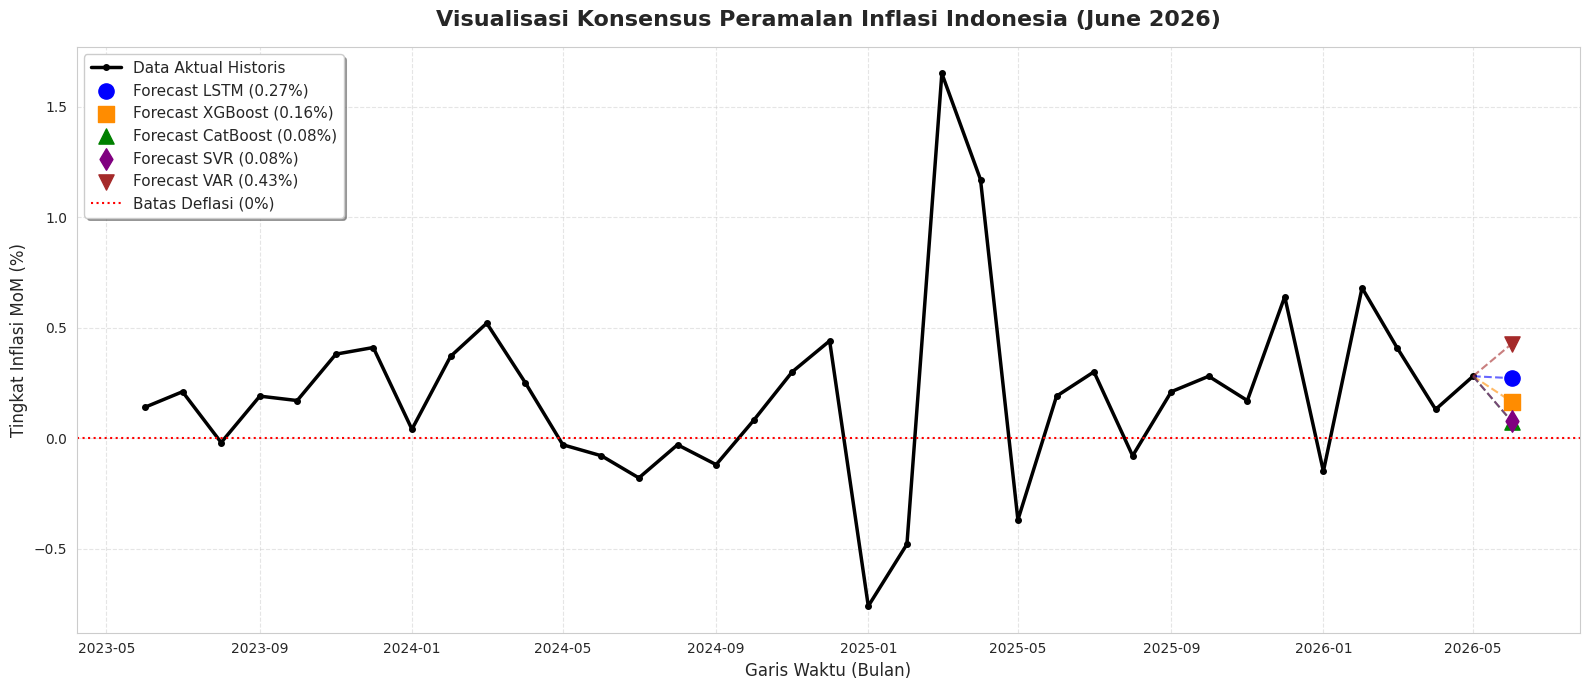

In [33]:
# PREDIKSI 1 BULAN KE DEPAN
# TENTUKAN TANGGAL PREDIKSI
tanggal_terakhir = df_raw.index[-1]
tanggal_prediksi = tanggal_terakhir + pd.DateOffset(months=1)
nilai_aktual_terakhir = df_raw['Inflasi_MoM'].iloc[-1]

# LSTM FORECAST 
data_terakhir_12_bulan = data_lstm.tail(jumlah_bulan_kebelakang).copy()
input_skala_lstm = alat_skala_final_lstm.transform(data_terakhir_12_bulan.values)
input_lstm_3d = input_skala_lstm.reshape(1, jumlah_bulan_kebelakang, n_fitur_lstm)
tebakan_lstm_skala = model_terbaik_lstm.predict(input_lstm_3d, verbose=0)
hasil_prediksi_lstm = kembalikan_ke_asli_inflasi(tebakan_lstm_skala, alat_skala_final_lstm)[0]

# SETTING INPUT UMUM (XGBOOST, CATBOOST, SVR) 
baris_input = pd.Series(index=X_fitur_xgb.columns, dtype='float64')
baris_input['kuartal'] = tanggal_prediksi.quarter
baris_input['bulan_sin'] = np.sin(2 * np.pi * tanggal_prediksi.month / 12.0)
baris_input['bulan_cos'] = np.cos(2 * np.pi * tanggal_prediksi.month / 12.0)

for col in df_raw.columns:
    if col != 'Inflasi_MoM' and col in X_fitur_xgb.columns:
        baris_input[col] = df_raw[col].iloc[-1]

for i in [1, 2, 3, 6, 12]:
    baris_input[f'inflasi_lag_{i}'] = df_raw['Inflasi_MoM'].iloc[-i]

baris_input['inflasi_rolling_mean_3']  = df_raw['Inflasi_MoM'].iloc[-3:].mean()
baris_input['inflasi_rolling_std_3']   = df_raw['Inflasi_MoM'].iloc[-3:].std()
baris_input['inflasi_rolling_mean_6']  = df_raw['Inflasi_MoM'].iloc[-6:].mean()
baris_input['inflasi_rolling_std_6']   = df_raw['Inflasi_MoM'].iloc[-6:].std()
baris_input['inflasi_rolling_mean_12'] = df_raw['Inflasi_MoM'].iloc[-12:].mean()

# Ubah ke DataFrame dan selaraskan urutan kolom 
df_input_tabular = pd.DataFrame([baris_input])[X_fitur_xgb.columns]

# MODEL 2, 3, 4: TABULAR FORECAST
hasil_prediksi_xgb = model_terbaik_xgb.predict(df_input_tabular)[0]
hasil_prediksi_cat = model_terbaik_cat.predict(df_input_tabular)[0]
hasil_prediksi_svr = model_terbaik_svr.predict(df_input_tabular)[0]

# VAR FORECAST
# Menggunakan df_fitur_var secara konsisten untuk forecast VAR
input_terakhir_var = df_fitur_var.values[-lag_optimal_var:]
tebakan_var_mentah = model_terbaik_var.forecast(y=input_terakhir_var, steps=1)

# Mencari indeks kolom target dari list kolom df_fitur_var
indeks_inflasi_col = list(df_fitur_var.columns).index('Inflasi_MoM')
hasil_prediksi_var = tebakan_var_mentah[0][indeks_inflasi_col]

#MENAMPILKAN
print(f"FORECAST INFLASI INDONESIA : {tanggal_prediksi.strftime('%B %Y')}")
print(f"1. Deep Learning (LSTM)          : {hasil_prediksi_lstm:.2f}%")
print(f"2. Tree Boosting (XGBoost)       : {hasil_prediksi_xgb:.2f}%")
print(f"3. Tree Boosting (CatBoost)      : {hasil_prediksi_cat:.2f}%")
print(f"4. Support Vector Machine (SVR)  : {hasil_prediksi_svr:.2f}%")
print(f"5. Ekonometrika Makro (VAR)      : {hasil_prediksi_var:.2f}%")


# VISUALISASI GRAFIK GABUNGAN 
plt.figure(figsize=(16, 7))

# Plot Data Historis Aktual (36 Bulan Terakhir)
periode_tampil = 36 
plt.plot(df_raw.index[-periode_tampil:], df_raw['Inflasi_MoM'].iloc[-periode_tampil:], 
         label='Data Aktual Historis', color='black', linewidth=2.5, marker='o', markersize=4)

# konfigurasi plot agar perulangan visualisasi menjadi efisien
plot_config = {
    'LSTM': (hasil_prediksi_lstm, 'blue', 'o'),
    'XGBoost': (hasil_prediksi_xgb, 'darkorange', 's'),
    'CatBoost': (hasil_prediksi_cat, 'green', '^'),
    'SVR': (hasil_prediksi_svr, 'purple', 'd'),
    'VAR': (hasil_prediksi_var, 'brown', 'v')
}

# garis proyeksi terputus dan marker prediksi untuk setiap model
for nama_model, (nilai_pred, warna, penanda) in plot_config.items():
    plt.plot([tanggal_terakhir, tanggal_prediksi], [nilai_aktual_terakhir, nilai_pred], 
             color=warna, linestyle='--', linewidth=1.5, alpha=0.6)
    plt.scatter(tanggal_prediksi, nilai_pred, color=warna, s=120, zorder=5, marker=penanda,
                label=f'Forecast {nama_model} ({nilai_pred:.2f}%)')

# Batas Deflasi
plt.axhline(0, color='red', linestyle=':', linewidth=1.5, label='Batas Deflasi (0%)')

plt.title(f"Visualisasi Konsensus Peramalan Inflasi Indonesia ({tanggal_prediksi.strftime('%B %Y')})", 
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Garis Waktu (Bulan)", fontsize=12)
plt.ylabel("Tingkat Inflasi MoM (%)", fontsize=12)
plt.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()